In [1]:
%load_ext autotime

import scarf
scarf.__version__

'1.0.0'

time: 2.23 s (started: 2026-07-11 00:04:08 +02:00)


In [2]:
scarf.fetch_dataset(
    dataset_name='tenx_10K_pbmc-v1_atacseq',
    save_path='scarf_datasets'
)

time: 20.6 s (started: 2026-07-11 00:04:10 +02:00)


In [3]:
reader = scarf.CrH5Reader(
    'scarf_datasets/tenx_10K_pbmc-v1_atacseq/data.h5'
)
reader.assayFeats

,ATAC
type,Peaks
start,0
end,89796
nFeatures,89796


time: 40 ms (started: 2026-07-11 00:04:31 +02:00)


In [4]:
writer = scarf.CrToZarr(
    reader,
    zarr_loc=f'scarf_datasets/tenx_10K_pbmc-v1_atacseq/data.zarr',
    chunk_size=(1000, 2000)
)
writer.dump(batch_size=1000)

time: 2min 1s (started: 2026-07-11 00:04:31 +02:00)


In [5]:
ds = scarf.DataStore(
    'scarf_datasets/tenx_10K_pbmc-v1_atacseq/data.zarr', 
    nthreads=4
)

time: 21.6 s (started: 2026-07-11 00:06:33 +02:00)


247 cells flagged for filtering out using attribute ATAC_nCounts



294 cells flagged for filtering out using attribute ATAC_nFeatures



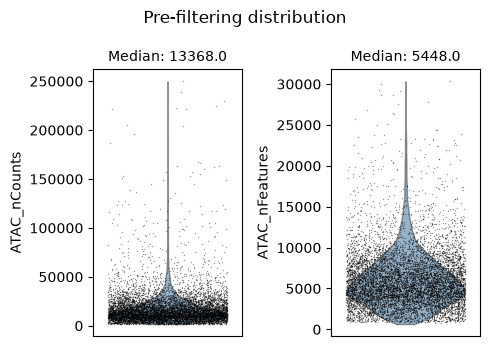

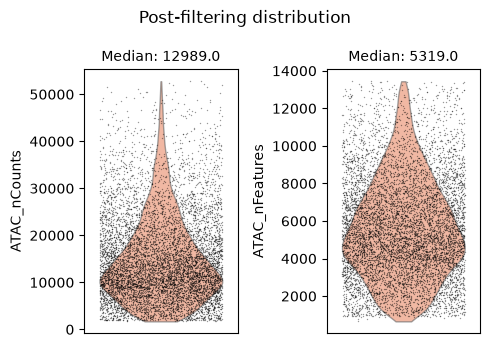

time: 1.43 s (started: 2026-07-11 00:06:54 +02:00)


In [6]:
ds.auto_filter_cells()

In [7]:
ds.mark_prevalent_peaks(top_n=25000)

time: 46.6 s (started: 2026-07-11 00:06:56 +02:00)


In [8]:
ds.ATAC.feats.head()

,I,ids,names,nCells,dropOuts,I__prevalent_peaks,stats_I_prevalence
0,True,chr1:565107-565550,chr1:565107-565550,83,8645,False,0.206181
1,True,chr1:569174-569639,chr1:569174-569639,199,8529,False,0.350725
2,True,chr1:713460-714823,chr1:713460-714823,2486,6242,True,1.993573
3,True,chr1:752422-753038,chr1:752422-753038,432,8296,True,0.680701
4,True,chr1:762106-763359,chr1:762106-763359,1878,6850,True,1.570790


time: 461 ms (started: 2026-07-11 00:07:42 +02:00)


In [9]:
ds.make_graph(
    feat_key='prevalent_peaks',
    k=21,
    dims=50,
    n_centroids=100,
    lsi_skip_first=True,
)

make_graph step 1/7: normalize expression matrix (computing)



make_graph step 1/7: normalize expression matrix finished in 17.6s (computing)



make_graph step 2/7: normalization statistics (computing)



make_graph step 2/7: normalization statistics finished in 0.0s (computing)



make_graph step 3/7: dimension reduction, ANN index, and kmeans (computing)



...

ANN recall: 99.36%



make_graph step 7/7: finalize graph metadata (computing)



make_graph step 7/7: finalize graph metadata finished in 0.0s (computing)



make_graph finished in 43.9s (7/7 steps, 43.8s in logged steps)



time: 43.9 s (started: 2026-07-11 00:07:43 +02:00)


In [10]:
ds.run_umap(
    n_epochs=500,
    min_dist=0.1, 
    spread=1, 
    parallel=True
)

Training UMAP:   0%|                                                                                          …

time: 10.8 s (started: 2026-07-11 00:08:27 +02:00)


/home/parashar/scarf/scarf/metadata.py:344: RuntimeWarning: overflow encountered in cast
  a = np.empty(self.N).astype(values.dtype)


In [11]:
ds.run_leiden_clustering(resolution=0.6)

time: 1.18 s (started: 2026-07-11 00:08:38 +02:00)


In [12]:
ds.cells.head()

,I,ids,names,ATAC_nCounts,ATAC_nFeatures,ATAC_UMAP2,ATAC_leiden_cluster,ATAC_UMAP1
0,True,AAACGAAAGAGCGAAA-1,AAACGAAAGAGCGAAA-1,13187.0,5546.0,-7.729205,1,-6.472432
1,True,AAACGAAAGAGTTTGA-1,AAACGAAAGAGTTTGA-1,16074.0,6586.0,-10.811559,4,-6.999135
2,True,AAACGAAAGCGAGCTA-1,AAACGAAAGCGAGCTA-1,28009.0,9214.0,0.279873,7,6.084880
3,False,AAACGAAAGGCTTCGC-1,AAACGAAAGGCTTCGC-1,221747.0,30325.0,NaN,-1,NaN
4,True,AAACGAAAGTGCTGAG-1,AAACGAAAGTGCTGAG-1,11440.0,4922.0,-7.043410,1,-6.475428


time: 87.2 ms (started: 2026-07-11 00:08:39 +02:00)


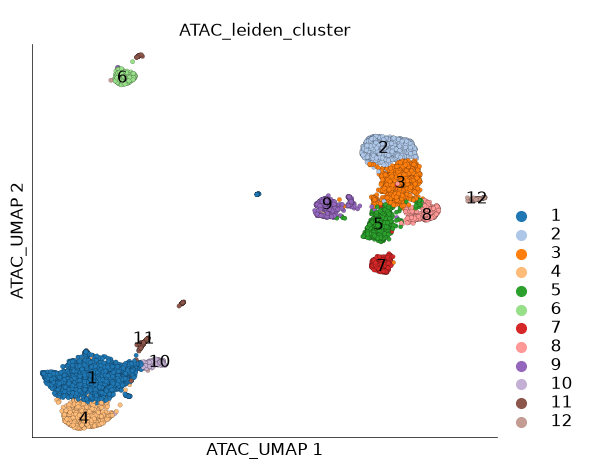

time: 300 ms (started: 2026-07-11 00:08:39 +02:00)


In [13]:
ds.plot_layout(
    layout_key='ATAC_UMAP', 
    color_by='ATAC_leiden_cluster'
)

In [14]:
scarf.fetch_dataset(
    dataset_name='annotations', 
    save_path='scarf_datasets'
)

time: 8.77 s (started: 2026-07-11 00:08:39 +02:00)


In [15]:
ds.add_melded_assay(
    from_assay='ATAC',
    external_bed_fn='scarf_datasets/annotations/human_GRCh37_gencode_v38_gene_body.bed.gz',
    peaks_col='ids',
    renormalization=False,
    assay_label='GeneScores',
    assay_type='RNA'
)

Chromosome chrM not in the input peak coordinates



33935/62446 features did not overlap with any peak



Minimum cell count (6.539499236477921) is lower than size factor multiplier (1000)



time: 1min 47s (started: 2026-07-11 00:08:48 +02:00)


In [16]:
ds

DataStore has 8426 (8728) cells with 2 assays: ATAC GeneScores
   Cell metadata:
            'I', 'ids', 'names', 'GeneScores_percentMito', 'ATAC_nFeatures', 
            'GeneScores_percentRibo', 'ATAC_nCounts', 'GeneScores_nCounts', 'GeneScores_nFeatures', 'ATAC_UMAP2', 
            'ATAC_leiden_cluster', 'ATAC_UMAP1'
   ATAC assay has 86049 (89796) features and following metadata:
            'I', 'ids', 'names', 'dropOuts', 'nCells', 
            'I__prevalent_peaks'
   GeneScores assay has 28357 (62446) features and following metadata:
            'I', 'ids', 'names', 'nCells', 'dropOuts', 
          

time: 76.1 ms (started: 2026-07-11 00:10:35 +02:00)


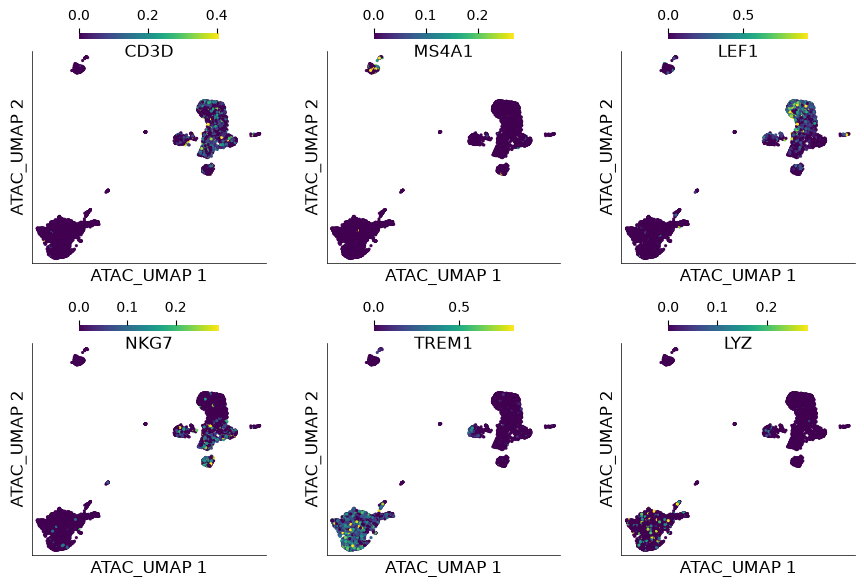

time: 1min 4s (started: 2026-07-11 00:10:35 +02:00)


In [17]:
ds.plot_layout(
    layout_key='ATAC_UMAP', from_assay='GeneScores', 
    color_by=['CD3D', 'MS4A1', 'LEF1', 'NKG7', 'TREM1', 'LYZ'],
    clip_fraction=0.01, 
    n_columns=3,
    width=3,
    height=3,
    point_size=5,
    scatter_kwargs={'lw': 0.01},
)